# Anomaly Detection in Mobile Networks

This notebook describes anomaly detection methods for drive test data.

**Target audience:** telecom engineers and PhD students  

## Learning objectives
1. Compute descriptive statistics for the target KPI
2. Apply and compare rule-based univariate anomaly detectors
3. Generate a controlled contaminated dataset with known inliers and outliers for method validation
4. Understand the robust covariance method for bi-variate data 
5. Evaluate anomaly-detection performance with accuracy metrics 


## Notebook flow
1. Environment setup  
2. Load the clean dataset  
3. Rule-based anomaly detection
4. Robust Covariance (2D)

## 1. Environment Setup

This cell imports the scientific Python stack used throughout the notebook and configures the analysis environment.

In [8]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.covariance import EmpiricalCovariance, MinCovDet, EllipticEnvelope
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve, 
    auc
)
from sklearn.svm import OneClassSVM

from IPython.display import display

from srcs.misc import stat_summary
from srcs.plot_functions import plot_distribution_pair, plot_outlier_detection

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid", context="talk")

## 2. Load the Clean Dataset

This cell specifies the expected dataset path, checks for the CSV file's existence, and loads it into a pandas DataFrame. Specifically, the dataset is read from the local `datasets/` directory. Additionally, a copy of the cleaned dataset is saved to ensure that subsequent anomaly detection processes remain auditable.

In [9]:
DATA_FILE = "data_clean"
DATA_PATH = Path("datasets") / f"{DATA_FILE}.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'. "
        "Place the CSV in the expected folder or update DATA_PATH before running this notebook."
    )

data = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1",
    sep=",",
    decimal=".",
    low_memory=False,
)

print(f"Cleaned dataset shape: {data.shape[0]:,} rows x {data.shape[1]:,} columns")
display(data.head())

Cleaned dataset shape: 1,001 rows x 120 columns


,resets.sent.a2b,ack.pkts.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,max.segm.size.b2a,min.segm.size.a2b,min.segm.size.b2a,avg.segm.size.a2b,max.win.adv.a2b,max.win.adv.b2a,min.win.adv.a2b,avg.win.adv.a2b,min.non.zero.owin.b2a,avg.owin.a2b,avg.owin.b2a,wavg.owin.a2b,initial.window.bytes.b2a,initial.window.pkts.b2a,truncated.data.a2b,data.xmit.time.a2b,data.xmit.time.b2a,idletime.max.b2a,throughput.a2b,rtt.min.a2b,rtt.max.a2b,rtt.avg.a2b,rtt.stdev.a2b,rtt.from.3whs.a2b,rtt.full.sz.smpls.a2b,rtt.full.sz.min.a2b,rtt.full.sz.max.a2b,segs.cum.acked.a2b,triple.dupacks.a2b,max.retrans.a2b,min.retr.time.a2b,avg.retr.time.a2b,sdv.retr.time.a2b,fin.pkts.sent.a2b,rtt.min.b2a,rtt.max.b2a,rtt.avg.b2a,rtt.stdev.b2a,rtt.from.3whs.b2a,rtt.full.sz.smpls.b2a,rtt.full.sz.min.b2a,rtt.full.sz.max.b2a,rtt.full.sz.avg.b2a,post.loss.acks.b2a,rtt.min.last.b2a,rtt.max.last.b2a,rtt.avg.last.b2a,rtt.sdv.last.b2a,segs.cum.acked.b2a,triple.dupacks.b2a,max.retrans.b2a,min.retr.time.b2a,max.retr.time.b2a,avg.retr.time.b2a,sdv.retr.time.b2a,syn.pkts.sent.b2a,fin.pkts.sent.b2a,duplicate.acks.b2a,abs.downlinkdelay.min,abs.downlinkdelay.50,abs.downlinkdelay.75,abs.downlinkdelay.max,abs.uplinkdelay.25,abs.uplinkdelay.50,abs.uplinkdelay.avg,abs.uplinkdelay.75,abs.uplinkdelay.max,abs.downlinkdeltadelay.25,abs.uplinkdeltadelay.avg,abs.rtt.min,abs.rtt.25,abs.rtt.50,abs.rtt.avg,abs.rtt.75,abs.rtt.max,abs.cwin.min,abs.cwin.25,abs.cwin.50,abs.cwin.avg,abs.cwin.75,abs.cwin.max,abs.rwin.25,abs.rwin.50,abs.rwin.75,abs.rwin.max,abs.winratio.min,abs.winratio.25,abs.winratio.50,abs.winratio.avg,abs.winratio.75,abs.winratio.max,abs.radiobuffer.min,abs.radiobuffer.25,abs.radiobuffer.50,abs.radiobuffer.avg,abs.radiobuffer.75,abs.radiobuffer.max,abs.idletime.50,abs.idletime.avg,abs.idletime.75,abs.idletime.max,abs.segmentsizes.min,abs.segmentsizes.25,abs.segmentsizes.50,abs.segmentsizes.max,abs.packetlost.sum,abs.instanttp.min,abs.burst.sum,abs.rtoevents.sum,abs.theoricalmaxtp.avg,abs.theoricalmaxtp.max,transfer.datarate
0,100.0,24629.0,8.0,0.0,43.0,0.0,439348.0,17.0,65236.0,232.0,4.0,231.0,41937920.0,1946752.0,1638400.0,40000544.0,5.0,5.0,153524.0,5.0,24984.0,9.0,460.0,0.0,7.328,264.8,155.0,23.8,54.2,46.4,0.0,38.6,1.0,30.6,38.6,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,17.8,0.4,0.5,0.5,1.0,0.2,0.5,0.5,2.0,0.0,0.0,0.0,0.0,17621.0,2.0,0.0,0.0,0.0,0.00,0.0,5.0,0.0,41.0,3.0,38.0,54.0,334.0,8.0,10.0,8.460015,11.0,46.0,25.0,301.460015,0.0,38.0,48.0,55.818960,62.0,351.0,0.0,3167756.0,3475141.0,3.852855e+06,3913768.0,7352717.0,41937920.0,41937920.0,41937920.0,41937920.0,0.058522,0.076108,0.082864,0.096487,0.102346,0.292707,0.0,1606174.75,2148816.0,2.401342e+06,2784797.25,11976195.0,0.0,0.173705,0.0,252.0,1.0,2776.0,6940.0,65236.0,28.0,0.00008,14.0,3.0,3.983938e+09,3.131014e+13,448375.109
1,198.0,15636.0,42.0,0.0,22.0,0.0,72488.0,3190.0,55520.0,232.0,1.0,231.0,31455232.0,1599360.0,1638400.0,25549822.0,5.0,5.0,881001.0,3.0,19432.0,6.0,460.0,0.0,7.406,163.1,155.0,18.3,48.0,33.9,13.9,20.8,2.0,20.1,32.1,0.0,5.0,0.0,0.0,0.0,0.0,3.0,0.0,44.9,0.7,1.3,0.7,2.0,0.2,1.2,0.7,411.0,0.0,0.3,0.3,0.0,11922.0,62.0,1.0,0.0,170.2,34.04,0.0,5.0,0.0,2587.0,3.0,29.0,301.0,1727.0,1.0,11.0,-91.487522,14.0,200.0,12.0,1513.512478,1.0,27.0,42.0,135.827804,191.0,1741.0,0.0,1042825.0,1844469.0,3.130090e+06,3082700.0,10960755.0,21106688.0,31454208.0,31455232.0,31455232.0,0.013998,0.036512,0.059114,0.156073,0.209670,0.637286,0.0,438221.25,789585.5,1.207837e+06,1504034.50,9483651.0,0.0,0.315479,0.0,155.0,0.0,1388.0,2776.0,55520.0,397.0,0.00008,191.0,8.0,3.452638e+02,6.846370e+04,131054.310
2,5.0,25907.0,6.0,0.0,40.0,0.0,440036.0,951.0,65236.0,232.0,4.0,231.0,41943040.0,1365760.0,1638400.0,40072479.0,5.0,5.0,1084167.0,0.0,44416.0,10.0,460.0,0.0,7.351,191.0,155.0,12.7,20.5,18.4,0.0,20.5,1.0,16.3,20.5,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,44.2,0.5,1.9,0.6,1.0,0.3,0.6,0.6,521.0,0.0,0.0,0.0,0.0,22011.0,256.0,0.0,0.0,0.0,0.00,0.0,5.0,0.0,3114.0,3.0,37.0,54

## 3. Rule-based Anomaly Detection

- **IQR rule:** flag values outside the interval  
$$[Q_1 - 1.5\,IQR,\; Q_3 + 1.5\,IQR]$$
- **Z-score rule:** flag values such that  
  $$\left|\frac{x-\mu}{\sigma}\right| > 3 $$
- **MAD rule:** flag values such that  
$$ \left|0.6745\,\frac{x-\mathrm{median}}{\mathrm{MAD}}\right| > 3 $$

          transfer.datarate  log10(transfer.datarate)
count             1001.0000                 1001.0000
mean            393434.7491                    5.5131
std             198472.1685                    0.3248
min               2408.9670                    3.3818
25%             253083.9300                    5.4033
50%             381348.1200                    5.5813
75%             519678.9110                    5.7157
max            1275028.0490                    6.1055
skewness             0.4792                   -2.2380
kurtosis             0.4115                    8.1728


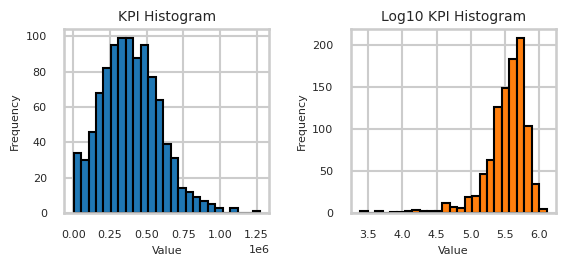

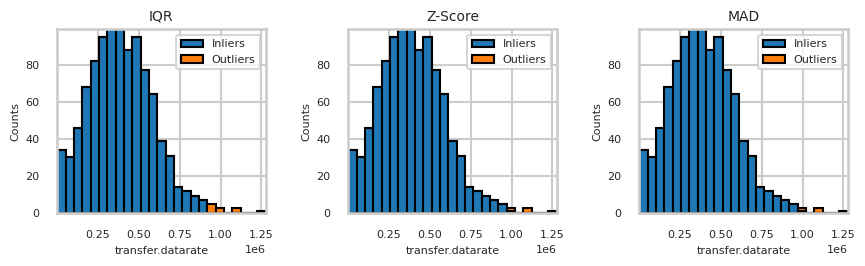

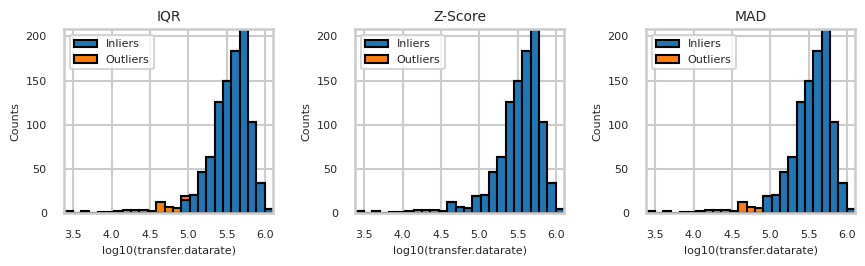

In [10]:
# -------------------------------------------------------------------
# KPI selection
# -------------------------------------------------------------------
target_kpi = 'transfer.datarate'
kpi_aux = data[target_kpi]
kpi_aux_log = np.log10(kpi_aux)

summary = pd.concat(
    [
        stat_summary(kpi_aux).rename(target_kpi),
        stat_summary(kpi_aux_log).rename(f"log10({target_kpi})"),
    ],
    axis=1,
)
print(summary.to_string(float_format=lambda x: f"{x:.4f}"))

# -------------------------------------------------------------------
# Run plots
# -------------------------------------------------------------------
plot_distribution_pair(kpi_aux, kpi_aux_log)

outliers_kpi = plot_outlier_detection(kpi_aux, xlabel=target_kpi)
outliers_kpi_log = plot_outlier_detection(
    kpi_aux_log,
    xlabel=f"log10({target_kpi})",
    suffix=" (Log10 Transformed)",
)

## 4. Robust Covariance (2D)

This cell introduces **multivariate anomaly detection** using a synthetic two-dimensional dataset with known contamination.

- `make_contaminated_data(...)` generates Gaussian inliers and injected outliers.
- `EmpiricalCovariance` estimates the classical maximum-likelihood covariance matrix.
- `MinCovDet` estimates a **robust covariance matrix** using the Minimum Covariance Determinant (MCD).
- `EllipticEnvelope` uses the robust covariance estimate together with the assumed contamination rate to classify each sample as an inlier or an outlier.

In [11]:
def make_contaminated_data(
    n_samples: int = 125,
    n_outliers: int = 25,
    n_features: int = 2,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate a 2D contaminated Gaussian dataset.

    Inliers  ~ N(0, diag(2, 1))
    Outliers ~ N(0, diag(1, 7))
    """
    cov_normal = np.eye(n_features)
    cov_normal[0, 0] = 2.0
    
    cov_outliers = np.eye(n_features)
    cov_outliers[1, 1] = 7.0
    
    n_inliers = n_samples - n_outliers

    inliers = np.dot(np.random.randn(n_inliers, n_features), cov_normal)
    outliers = np.dot(np.random.randn(n_outliers, n_features), cov_outliers)

    X = np.vstack([inliers, outliers])
    y_true = np.r_[np.zeros(n_inliers, dtype=bool), np.ones(n_outliers, dtype=bool)]
    return X, y_true

np.random.seed(7)
N_SAMPLES = 125
N_OUTLIERS = 25
N_FEATURES = 2
RANDOM_STATE = 42

X, y_true = make_contaminated_data(n_samples=N_SAMPLES, 
                                   n_outliers=N_OUTLIERS, 
                                   n_features=N_FEATURES)

contamination = N_OUTLIERS / N_SAMPLES

mle = EmpiricalCovariance().fit(X)
mcd = MinCovDet().fit(X)

print(f"MCD covariance:\n{mcd.covariance_}\n")
print(f"MLE covariance:\n{mle.covariance_}\n")

ee = EllipticEnvelope(contamination=contamination).fit(X)
detected = ee.predict(X) == -1

MCD covariance:
[[ 3.43921168 -0.08060231]
 [-0.08060231  1.78426485]]

MLE covariance:
[[ 3.13866208 -0.10437838]
 [-0.10437838  7.97169192]]



### Mahalanobis-distance Surfaces and Covariance Contours

This cell computes Mahalanobis-distance surfaces on a grid and visualizes the corresponding covariance contours.

- The left panel shows the **true synthetic data** together with the contours induced by the classical and robust covariance estimates.
- The right panel shows the **predicted labels** produced by `EllipticEnvelope`, again superimposed on the same distance contours.

For elliptical models, anomaly detection is driven by the Mahalanobis distance

$$d_M(x)=\sqrt{(x-\mu)^\top\Sigma^{-1}(x-\mu)}.$$

This visualization highlights a key idea from robust statistics: classical covariance estimates can be distorted by contamination, whereas MCD-based estimates preserve the geometry of the inlier cloud more reliably.

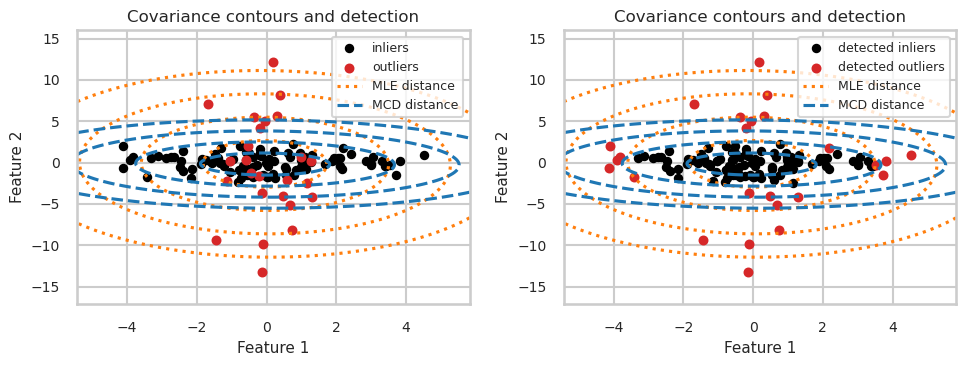

In [12]:
def _mahalanobis_surface(model, xlim, ylim, n_grid: int = 200):
    xx, yy = np.meshgrid(
        np.linspace(*xlim, n_grid),
        np.linspace(*ylim, n_grid),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = np.sqrt(model.mahalanobis(grid)).reshape(xx.shape)
    return xx, yy, zz

# Plot limits
pad = 0.15 * (X.max(axis=0) - X.min(axis=0))
xlim = (X[:, 0].min() - pad[0], X[:, 0].max() + pad[0])
ylim = (X[:, 1].min() - pad[1], X[:, 1].max() + pad[1])

xx, yy, zz_mle = _mahalanobis_surface(mle, xlim, ylim)
_, _, zz_mcd = _mahalanobis_surface(mcd, xlim, ylim)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# ------------------------------------------------------------
# 1) Scatter + covariance contours
# ------------------------------------------------------------
ax = axes[0]
ax.scatter(
        X[~y_true, 0], X[~y_true, 1],
        s=28, color="black", label="inliers"
    )
ax.scatter(
        X[y_true, 0], X[y_true, 1],
        s=32, color="tab:red", label="outliers"
    )

ax.contour(xx, yy, zz_mle, levels=[1, 2, 3, 4], colors="tab:orange", linestyles=":")
ax.contour(xx, yy, zz_mcd, levels=[1, 2, 3, 4], colors="tab:blue", linestyles="--")

# Legend entries for contours
ax.plot([], [], ":", color="tab:orange", label="MLE distance")
ax.plot([], [], "--", color="tab:blue", label="MCD distance")

ax.set_title("Covariance contours and detection", fontsize=12)
ax.set_xlabel("Feature 1", fontsize=11)
ax.set_ylabel("Feature 2", fontsize=11)
ax.tick_params(axis="both", labelsize=10)
ax.legend(fontsize=9, loc="upper right")


ax = axes[1]
ax.scatter(
        X[~detected, 0], X[~detected, 1],
        s=28, color="black", label="detected inliers"
    )
ax.scatter(
        X[detected, 0], X[detected, 1],
        s=32, color="tab:red", label="detected outliers"
    )

ax.contour(xx, yy, zz_mle, levels=[1, 2, 3, 4], colors="tab:orange", linestyles=":")
ax.contour(xx, yy, zz_mcd, levels=[1, 2, 3, 4], colors="tab:blue", linestyles="--")

# Legend entries for contours
ax.plot([], [], ":", color="tab:orange", label="MLE distance")
ax.plot([], [], "--", color="tab:blue", label="MCD distance")

ax.set_title("Covariance contours and detection", fontsize=12)
ax.set_xlabel("Feature 1", fontsize=11)
ax.set_ylabel("Feature 2", fontsize=11)
ax.tick_params(axis="both", labelsize=10)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

### Anomaly Detection Metrics

The cell then evaluates the detector with:

- the **confusion matrix**
- **accuracy**
- **precision**
- **recall / sensitivity**
- **F1-score**

Unlike univariate rules, covariance-based methods use the **joint structure** of multiple variables. This is important in anomaly detection because a sample can look normal in each individual feature while still being atypical in the multivariate feature space.

Confusion matrix:
[[90 10]
 [10 15]]
TN=90, FP=10, FN=10, TP=15

Metrics:
    accuracy: 0.8400
 sensitivity: 0.6000
 specificity: 0.9000
    f1_score: 0.6000


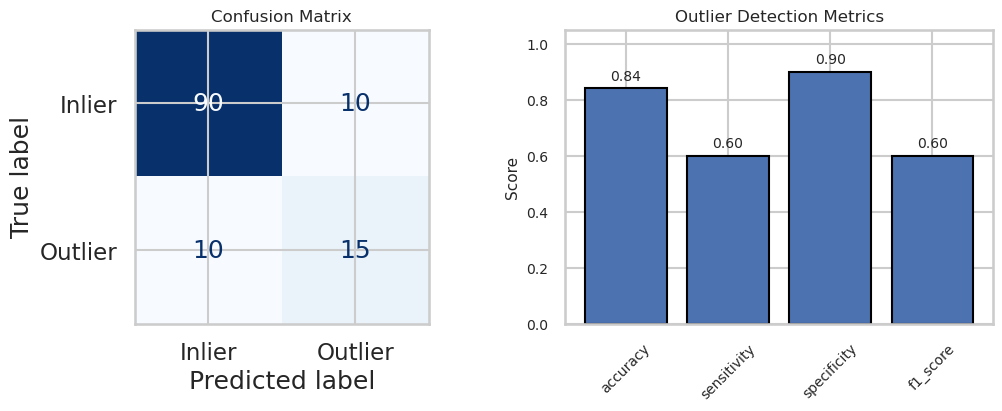

In [13]:
def evaluate_outlier_detection(y_true: np.ndarray, y_pred: np.ndarray):
    """
    Compute evaluation metrics for binary outlier detection.
    Positive class = outlier (True).
    """
    y_true = np.asarray(y_true, dtype=bool)
    y_pred = np.asarray(y_pred, dtype=bool)

    cm = confusion_matrix(y_true, y_pred, labels=[False, True])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": recall_score(~y_true, ~y_pred, zero_division=0),  # same as recall
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
    }

    return metrics, cm, (tn, fp, fn, tp)

# ------------------------------------------------------------
# Evaluate EllipticEnvelope detection
# ------------------------------------------------------------
metrics, cm, (tn, fp, fn, tp) = evaluate_outlier_detection(y_true, detected)

print("Confusion matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}\n")

print("Metrics:")
for name, value in metrics.items():
    print(f"{name:>12}: {value:.4f}")

# ------------------------------------------------------------
# Visualization: confusion matrix + metric bar chart
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# Confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Inlier", "Outlier"],
)
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix", fontsize=12)

# Metrics
metric_names = ["accuracy", "sensitivity", "specificity", "f1_score"]
metric_values = [metrics[m] for m in metric_names]

bars = axes[1].bar(metric_names, metric_values, edgecolor="black")
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_title("Outlier Detection Metrics", fontsize=12)
axes[1].tick_params(axis="x", rotation=45, labelsize=10)
axes[1].tick_params(axis="y", labelsize=10)

for bar, value in zip(bars, metric_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.show()

## 5. One Class Support Vector  (OC-SVM)

Metrics Linear OC-SVM:
    accuracy: 0.5964
 sensitivity: 1.0000
 specificity: 0.5535
    f1_score: 0.3226
Metrics Polynomial OC-SVM:
    accuracy: 0.5953
 sensitivity: 0.9602
 specificity: 0.5565
    f1_score: 0.3133


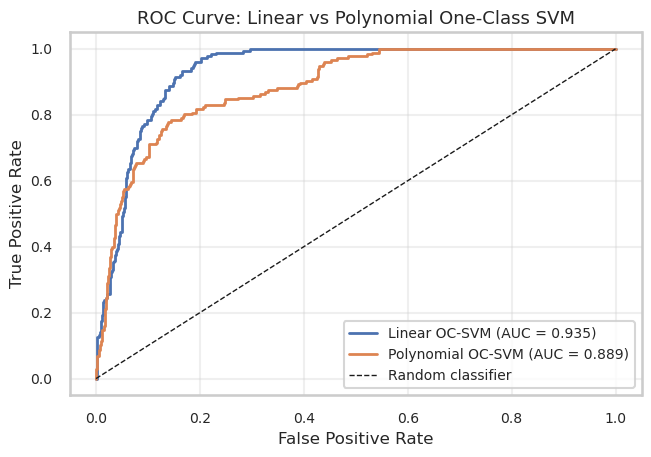

In [15]:
# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
X_ocsvm = np.load("datasets/6_cardio/X.npy")
y_true = np.load("datasets/6_cardio/y.npy").ravel()

# Ground-truth convention:
#   1 = outlier, 0 = inlier
# Change to outlier_label = -1 if your dataset uses {-1, 1}.
outlier_label = 1
y_bin = y_true == outlier_label

# ------------------------------------------------------------
# Fit One-Class SVM models
# ------------------------------------------------------------
ocsvm_linear = OneClassSVM(gamma="auto").fit(X_ocsvm)

ocsvm_poly = OneClassSVM(
    kernel="poly",
    degree=3,
    gamma="auto",
).fit(X_ocsvm)

# ------------------------------------------------------------
# Continuous anomaly scores
# Larger score = more anomalous
# decision_function is positive for inliers and negative for outliers,
# so we negate it for ROC analysis.
# ------------------------------------------------------------
scores_linear = -ocsvm_linear.decision_function(X_ocsvm).ravel()
scores_poly = ocsvm_poly.decision_function(X_ocsvm).ravel()

# Optional binary predictions
y_pred_linear = ocsvm_linear.predict(X_ocsvm) == -1
y_pred_poly = ocsvm_poly.predict(X_ocsvm) == 1

metrics, cm, (tn, fp, fn, tp) = evaluate_outlier_detection(y_bin, y_pred_linear)
metrics = {
        "accuracy": accuracy_score(y_bin, y_pred_linear),
        "sensitivity": recall_score(y_bin, y_pred_linear, zero_division=0),
        "specificity": recall_score(~y_bin, ~y_pred_linear, zero_division=0),  # same as recall
        "f1_score": f1_score(y_bin, y_pred_linear, zero_division=0),
    }
# Metrics
metric_names = ["accuracy", "sensitivity", "specificity", "f1_score"]
metric_values = [metrics[m] for m in metric_names]
print("Metrics Linear OC-SVM:")
for name, value in metrics.items():
    print(f"{name:>12}: {value:.4f}")


metrics, cm, (tn, fp, fn, tp) = evaluate_outlier_detection(y_bin, y_pred_linear)
metrics = {
        "accuracy": accuracy_score(y_bin, y_pred_poly),
        "sensitivity": recall_score(y_bin, y_pred_poly, zero_division=0),
        "specificity": recall_score(~y_bin, ~y_pred_poly, zero_division=0),  # same as recall
        "f1_score": f1_score(y_bin, y_pred_poly, zero_division=0),
    }
# Metrics
metric_names = ["accuracy", "sensitivity", "specificity", "f1_score"]
metric_values = [metrics[m] for m in metric_names]
print("Metrics Polynomial OC-SVM:")
for name, value in metrics.items():
    print(f"{name:>12}: {value:.4f}")

# ------------------------------------------------------------
# ROC curves and AUC
# ------------------------------------------------------------
fpr_linear, tpr_linear, _ = roc_curve(y_bin, scores_linear)
auc_linear = auc(fpr_linear, tpr_linear)

fpr_poly, tpr_poly, _ = roc_curve(y_bin, scores_poly)
auc_poly = auc(fpr_poly, tpr_poly)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(fpr_linear, tpr_linear, lw=2, label=f"Linear OC-SVM (AUC = {auc_linear:.3f})")
plt.plot(fpr_poly, tpr_poly, lw=2, label=f"Polynomial OC-SVM (AUC = {auc_poly:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve: Linear vs Polynomial One-Class SVM", fontsize=13)
plt.legend(fontsize=10, loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.tick_params(axis="both", labelsize=10)
plt.show()